In [26]:
pip install -qU -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [27]:
from typing import Dict, TypedDict, Optional, Any
from langgraph.graph import StateGraph, END
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI
from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.memory import MemorySaver 
from dotenv import load_dotenv
import json
import gradio as gr
import re
import os

# Load environment variables and set OpenAI API key
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv('grokAPIKeyGenAIClass')
os.environ["LANGSMITH_API_KEY"] = os.getenv('LANGSMITH_API_KEY')
os.environ["OPENAI_API_KEY"] = os.getenv('OPENAI_API_KEY')
os.environ["TAVILY_API_KEY"] = os.getenv('TAVILY_API_KEY')
os.environ["LANGSMITH_TRACING"] = os.getenv('LANGSMITH_TRACING')
os.environ["LANGSMITH_PROJECT"] = os.getenv('LANGSMITH_PROJECT')

In [28]:
gpt35_chat = ChatOpenAI(model="gpt-3.5-turbo-0125", temperature=0)

In [29]:
class State(TypedDict):
    query: str
    plans: Dict[str, Dict[str, Any]]
    approved: Optional[bool]
    selected_plan: Optional[Dict[str, Any]]
    feedback: Optional[str]
    response: Optional[str]
    tavilyResponse: Optional[str]

In [30]:
def build_plans_dict(json_text: str) -> Dict[str, Dict[str, Any]]:
    """
    Convert a JSON string of travel plans into a dictionary:
    {"Plan1": {...}, "Plan2": {...}} (max 5 entries).
    Handles malformed JSON gracefully.
    """
    keys = [
        "Destination",
        "Number of Days",
        "Why It's a Must-See",
        "Highlights & Activities",
        "Who It Suits"
    ]
    
    try:
        data = json.loads(json_text)
    except json.JSONDecodeError:
        start, end = json_text.find("["), json_text.rfind("]")
        if start != -1 and end > start:
            try:
                data = json.loads(json_text[start:end+1])
            except json.JSONDecodeError:
                return {}
        else:
            return {}
    if isinstance(data, dict):
        data = [data]
    elif not isinstance(data, list):
        return {}
    plans = []
    for item in data[:5]:
        if isinstance(item, dict) and item.get("Destination"):
            plan = {k: str(item.get(k, "")).strip().replace("\n", " ") for k in keys}
            plans.append(plan)
    return {f"Plan{i+1}": plan for i, plan in enumerate(plans)}

In [31]:
model_name = "openai/gpt-oss-120b"

def initiateTravelPlan(state: State) -> State:
    prompt= ChatPromptTemplate.from_template(
        "You are a travel planner."
        "Create a question that satify cutomer's query to plan a trip which can be used to search on the internet"
        "Query: {query}"
    )
    chain = prompt | ChatGroq(model=model_name, temperature=0)
    travelPlanQuestion = chain.invoke({"query": state["query"]}).content
    tavily_search = TavilySearchResults(max_results=3)
    search_docs = tavily_search.invoke(travelPlanQuestion)
    tavilyResponse=""
    for results in search_docs:
        content = results.get("content", "")
        tavilyResponse += f"\n\n{content}\n"
    return {
        "tavilyResponse": tavilyResponse,
    }

def suggestTravelPlan(state: State) -> State:
    schema_json = """[
    {
        "Destination": "string",
        "Number of Days": "string",
        "Why It's a Must-See": "string",
        "Highlights & Activities": "string",
        "Who It Suits": "string"
    }
    ]"""

    prompt = ChatPromptTemplate.from_template(
        "You are a travel planner. Using ONLY the context below, produce between 1 and 5 plans (never more than 5).\n"
        "Return STRICT JSON, and NOTHING else. Do not include markdown fences or explanations.\n\n"
        "JSON shape (array):\n"
        "{schema}\n\n"
        "Rules:\n"
        "• Exactly this key spelling and capitalization.\n"
        "• Each field is a single line string (no embedded newlines).\n"
        "• 1–2 sentences per field where applicable.\n"
        "• Max 5 items in the array.\n"
        "• Return ONLY valid JSON (no trailing commas, no comments).\n\n"
        "Context:\n"
        "{tavilyResponse}"
    )

    chain = prompt | ChatGroq(model=model_name, temperature=0)
    raw = chain.invoke({
        "tavilyResponse": state["tavilyResponse"],
        "schema": schema_json,
    }).content
    
    plans_dict = build_plans_dict(raw)
    return {"plans": plans_dict}

def humanApproval(state: State) -> State:
    approved = state.get("approved",None)
    
    if approved is True:
        if not state.get("selected_plan"):
            raise ValueError("approved=True but 'selected_plan' is missing.")
        return state

    if approved is False:
        if not state.get("feedback"):
            raise ValueError("approved=False but 'feedback' is missing.")
        return state

    # Neither approved nor rejected explicitly; pass-through
    return state


def applyFeedback(state: State) -> State:
    """Update the query using human feedback so the search can try again."""
    fb = (state.get("feedback") or "").strip()
    if fb:
        new_query = f"{state['query']} | preferences: {fb}"
        return {**state, "query": new_query}
    return state


def showSelectedPlan(state: State) -> State:
    """Format the selected plan for the user."""
    schema_json = """[
    {
        "Destination": "string",
        "Number of Days": "string",
        "Why It's a Must-See": "string",
        "Highlights & Activities": "string",
        "Who It Suits": "string"
    }
    ]"""
    plan = state.get("selected_plan") or {}
    if not plan:
        return {**state, "response": "No plan selected."}
    Context = "\n".join(f"{key}: {value}" for key, value in plan.items())
    prompt = ChatPromptTemplate.from_template(
        "You are a travel planner. Using ONLY the context and  customer query below,provide a detailed travel itenary\n"
        ""
        "Context:\n"
        "{Context}"
        "Query:\n"
        "{query}"
    )

    chain = prompt | ChatGroq(model=model_name, temperature=0)
    raw = chain.invoke({
        "query": state["query"],
        "Context": Context
    }).content
    return {**state, "response": raw}


In [32]:
def merge_state(old: State, new: State) -> State:
    """Merge old and new state objects."""
    merged = {**old, **{k: v for k, v in new.items() if v is not None}}
    return merged

def approval_router(state: State) -> str:
    # If approved and selected_plan exists, accept
    if state.get("approved") and state.get("selected_plan"):
        return "accept"

    if state.get("approved") is False:
        return "revise"
    # If neither provided yet, we still route to humanApproval
    return "pending"



workflow = StateGraph(State,merge=merge_state)

workflow.add_node("initiateTravelPlan", initiateTravelPlan)
workflow.add_node("suggestTravelPlan", suggestTravelPlan)
workflow.add_node("humanApproval", humanApproval)
workflow.add_node("applyFeedback", applyFeedback)
workflow.add_node("showSelectedPlan", showSelectedPlan)

workflow.add_edge("initiateTravelPlan","suggestTravelPlan")
workflow.add_edge("suggestTravelPlan","humanApproval")

workflow.add_conditional_edges(
    "humanApproval",
    approval_router,
    {
        "accept": "showSelectedPlan",
        "revise": "applyFeedback",
        "pending": "humanApproval",
    },
)

workflow.add_edge("applyFeedback", "initiateTravelPlan")
workflow.add_edge("showSelectedPlan", END)

workflow.set_entry_point("initiateTravelPlan")

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

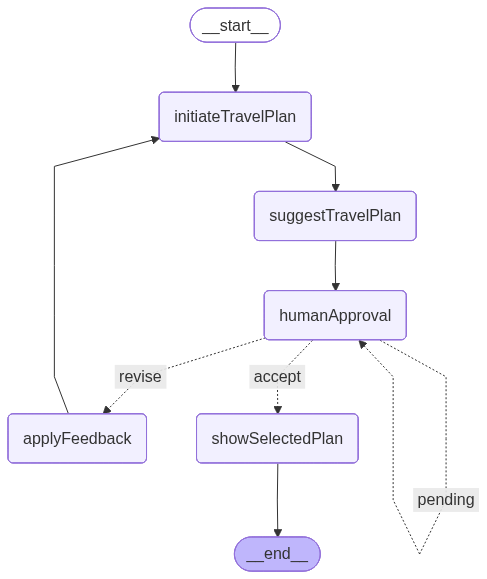

In [33]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [34]:
def stringify_plans(plans: Dict[str, Dict[str, Any]]) -> str:
    if not plans:
        return "No plans generated."
    lines = []
    for i, (key, p) in enumerate(plans.items(), start=1):
        title = p.get("Destination", key) or f"Plan {i}"
        lines.append(f"✅ Plan {i}: {title}")
        for k, v in p.items():
            lines.append(f"- {k}: {v}")
        lines.append("")
    return "\n".join(lines).strip()


def select_plan_by_index(plans: Dict[str, Dict[str, Any]], index_1_based: int) -> Dict[str, Any]:
    all_plans = list(plans.values())
    if not (1 <= index_1_based <= len(all_plans)):
        raise IndexError(f"Plan index {index_1_based} is out of range 1..{len(all_plans)}")
    return all_plans[index_1_based - 1]


def run_until_suggest(query: str, thread_id: str) -> State:
    initial_state: State = {
        "query": query,
        "plans": {},
        "approved": None,
        "selected_plan": None,
        "feedback": None,
        "response": None,
        "tavilyResponse": None,
    }

    state_after_suggest = None

    # Stream values and auto-interrupt right after suggestTravelPlan
    for value in app.stream(
        initial_state,
        config={"configurable": {"thread_id": thread_id}},
        stream_mode="values",
        interrupt_after=["suggestTravelPlan"],
    ):
        # In values mode, each `value` is the latest state snapshot.
        state_after_suggest = value

    if not state_after_suggest:
        raise RuntimeError("Did not reach `suggestTravelPlan`. Check graph wiring.")

    return state_after_suggest


def resume_after_user_choice(state_after_suggest: State, thread_id: str) -> State:
    last_value = state_after_suggest
    for value in app.stream(
        state_after_suggest,
        config={"configurable": {"thread_id": thread_id}},
        stream_mode="values",
    ):
        last_value = value
    return last_value

def run_travel_agent(query: str) -> Dict[str, Any]:
    """
    First call:
      - Runs the workflow until `suggestTravelPlan`
      - Returns ('thread_id', 'state_after_suggest', 'plans_text')
    Your UI should display plans_text, collect user action, then call continue_travel_agent().
    """
    thread_id = "travel_session_1"  # replace with per-user/per-chat thread id in real app
    state_after_suggest = run_until_suggest(query, thread_id=thread_id)
    plans_text = stringify_plans(state_after_suggest.get("plans", {}))
    return {
        "thread_id": thread_id,
        "state_after_suggest": state_after_suggest,
        "plans_text": plans_text,
    }


def continue_travel_agent(
    thread_id: str,
    state_after_suggest: State,
    *,
    approved: bool,
    selected_index: Optional[int] = None,
    feedback: Optional[str] = None,
) -> Dict[str, Any]:
    updated = dict(state_after_suggest)  # shallow copy

    if approved:
        if selected_index is None:
            raise ValueError("approved=True requires selected_index (1-based).")
        updated["approved"] = True
        updated["selected_plan"] = select_plan_by_index(updated["plans"], selected_index)
        updated["feedback"] = None

        # Run to completion
        last_value = updated
        for value in app.stream(
            updated,
            config={"configurable": {"thread_id": thread_id}},
            stream_mode="values",
        ):
            last_value = value
        return {"final_state": last_value}

    # Rejection path: set feedback and PAUSE after next suggestions
    if not feedback:
        raise ValueError("approved=False requires 'feedback' string.")
    updated["approved"] = False
    updated["selected_plan"] = None
    updated["feedback"] = feedback

    # Stream but stop right after new suggestions
    new_state = None
    for value in app.stream(
        updated,
        config={"configurable": {"thread_id": thread_id}},
        stream_mode="values",
        interrupt_after=["suggestTravelPlan"],
    ):
        new_state = value
    if new_state is None:
        raise RuntimeError("Did not reach `suggestTravelPlan` after feedback.")

    return {
        "thread_id": thread_id,
        "state_after_suggest": new_state,
        "plans_text": stringify_plans(new_state.get("plans", {})),
    }



In [35]:
# Testing 1
# boot = run_travel_agent("Warm beach vacation in December with good nightlife")
# print("=== Suggested Plans ===\n")
# print(boot["plans_text"])

# cont = continue_travel_agent(
#     boot["thread_id"],
#     boot["state_after_suggest"],
#     approved=True,
#     selected_index=2
# )

# print("\n=== Final Itinerary ===\n")
# print(cont["final_state"]["response"])

In [36]:
# Testing 2
# boot = run_travel_agent("Warm beach vacation in December with good nightlife")
# print("=== Suggested Plans ===\n")
# print(boot["plans_text"])

# cont = continue_travel_agent(
#     boot["thread_id"],
#     boot["state_after_suggest"],
#     approved=False,
#     feedback="Prefer Europe, 5-7 days, culture + food markets, moderate budget"
# )

# print("\n=== New Suggested Plans ===\n")
# print(cont["plans_text"])

# cont2 = continue_travel_agent(
#     cont["thread_id"],
#     cont["state_after_suggest"],
#     approved=True,
#     selected_index=2
# )

# print("\n=== Final Itinerary ===\n")
# print(cont2["final_state"]["response"])


In [37]:
def _init_session_state():
    return {
        "mode": "awaiting_query",      # "awaiting_query" -> "awaiting_choice" -> "done"
        "thread_id": None,
        "state_after_suggest": None,   # latest paused state at suggestTravelPlan
    }

CHOOSE_RE = re.compile(r"^(?:choose|approve|select)\s+(\d+)\b", flags=re.I)
REJECT_RE = re.compile(r"^(?:reject|feedback|revise)\s*:\s*(.+)", flags=re.I)
RESTART_RE = re.compile(r"^(?:start\s*over|new\s*query)\b", flags=re.I)
SHOW_RE = re.compile(r"^(?:show\s*plans|list\s*plans|plans)$", flags=re.I)

HELP_TEXT = (
    "Here’s how to continue:\n"
    "- **Choose a plan**: `choose 2`\n"
    "- **Reject and refine**: `reject: Prefer Europe, 5-7 days, museums + food`\n"
    "- **Start over**: `start over` then send a new query\n"
    "- **Show plans again**: `show plans`\n"
)

def chat_reply(user_msg, history, session):
    # Initialize session state if missing
    if session is None or not isinstance(session, dict) or "mode" not in session:
        session = _init_session_state()

    msg = (user_msg or "").strip()
    if not msg:
        # No content, repeat instructions for the current mode
        if session["mode"] == "awaiting_query":
            return "Tell me what kind of trip you want (e.g., 'Beach vacation in December, budget-friendly').", session
        if session["mode"] == "awaiting_choice":
            return "I'm waiting for your choice. " + HELP_TEXT, session
        return "Type `start over` to begin a new plan.", session

    # 1) Waiting for the user's initial query
    if session["mode"] == "awaiting_query":
        # If user typed an explicit restart command, just acknowledge
        if RESTART_RE.match(msg):
            return "Okay, tell me what kind of trip you want.", session

        # Treat message as a fresh travel request
        boot = run_travel_agent(msg)
        session["thread_id"] = boot["thread_id"]
        session["state_after_suggest"] = boot["state_after_suggest"]
        session["mode"] = "awaiting_choice"

        response = (
            "I searched and prepared some options for you.\n\n"
            f"{boot['plans_text']}\n\n"
            + HELP_TEXT
        )
        return response, session

    # 2) Waiting for user choice/feedback on suggested plans
    if session["mode"] == "awaiting_choice":

        # Restart flow explicitly
        if RESTART_RE.match(msg):
            session = _init_session_state()
            return "Okay, tell me what kind of trip you want.", session

        # Re-show current plans
        if SHOW_RE.match(msg):
            if session["state_after_suggest"] and "plans" in session["state_after_suggest"]:
                return "Please choose a plan with `choose N` or refine with `reject: ...`.", session
            return "No plans available yet. Start with a new query.", session

        # Approve pattern: choose N
        m_choose = CHOOSE_RE.match(msg)
        if m_choose:
            try:
                idx = int(m_choose.group(1))
            except ValueError:
                return "I couldn't parse that plan number. Try `choose 1`.", session

            try:
                cont = continue_travel_agent(
                    session["thread_id"],
                    session["state_after_suggest"],
                    approved=True,
                    selected_index=idx,
                )
            except Exception as e:
                return f"Error while approving plan #{idx}: {e}", session

            final_state = cont.get("final_state", {})
            itinerary = final_state.get("response") or "Itinerary generated."
            session["mode"] = "done"
            return itinerary, session

        # Reject pattern: reject: feedback text
        m_reject = REJECT_RE.match(msg)
        if m_reject:
            feedback = m_reject.group(1).strip()
            if not feedback:
                return "Please include your preferences after `reject:`.", session

            try:
                cont = continue_travel_agent(
                    session["thread_id"],
                    session["state_after_suggest"],
                    approved=False,
                    feedback=feedback,
                )
            except Exception as e:
                return f"Error while refining with feedback: {e}", session

            # After rejection, we PAUSE again at the next suggestions
            if "state_after_suggest" in cont and "plans_text" in cont:
                session["state_after_suggest"] = cont["state_after_suggest"]
                # Remain in awaiting_choice mode for the new set of plans
                response = (
                    "Got it — I refined the options based on your feedback.\n\n"
                    f"{cont['plans_text']}\n\n"
                    + HELP_TEXT
                )
                return response, session

            # Fallback
            return "I tried to refine the plans, but didn't receive new suggestions.", session

        # If the user types a fresh natural-language request here, treat as restart
        if len(msg.split()) > 3 and ":" not in msg and not msg.lower().startswith(("choose", "approve", "select")):
            # Soft restart with a new query
            boot = run_travel_agent(msg)
            session["thread_id"] = boot["thread_id"]
            session["state_after_suggest"] = boot["state_after_suggest"]
            session["mode"] = "awaiting_choice"
            response = (
                "New request received. Here are fresh suggestions:\n\n"
                f"{boot['plans_text']}\n\n"
                + HELP_TEXT
            )
            return response, session

        # Otherwise, guide the user
        return "I didn't catch that. " + HELP_TEXT, session

    # 3) Done (itinerary produced) — allow quick restart
    if session["mode"] == "done":
        if RESTART_RE.match(msg):
            session = _init_session_state()
            return "Okay, tell me what kind of trip you want.", session
        return "You're all set! Type `start over` to plan another trip.", session


# Build the Gradio app
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("## ✈️ Travel Planner (Chat Mode)\nStart by telling me what kind of trip you want.")
    session = gr.State(_init_session_state())

    gr.ChatInterface(
        fn=chat_reply,
        additional_inputs=[session],
        additional_outputs=[session],
        title="Travel Planner",
        description="Type your travel request to get suggested plans. Then reply with `choose N` or `reject: <feedback>`.",
    )

# Launch in Jupyter or as a standalone app:
demo.launch()


/opt/anaconda3/envs/RAGenv/lib/python3.13/site-packages/gradio/chat_interface.py:348: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
